# Single Attribution Analysis

This notebook computes Integrated Gradients attributions for suffix predictions.
It samples suffix predictions directly from the model (simple, no dropout, one sample per prediction)
without relying on pre-computed results.

## 1. Setup

In [1]:
import sys
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from collections import defaultdict

# Add parent directories to path
sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')

# Import model and interpretability tool
from model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from interpretability import InterpretabilityTool
from evaluation.evaluation import Evaluation

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 2. Configuration

**Edit this cell to configure the analysis:**

In [2]:
# ============================================================
# USER CONFIGURATION
# ============================================================

# Paths
MODEL_PATH = '../../../notebooks/training_variational_dropout/Helpdesk/Helpdesk_full_grad_norm_philipp_4layer.pkl'
DATA_PATH = '../../../../encoded_data/test_philipp/helpdesk_all_5_test.pkl'

# Sampling configuration
MAX_CASES = 50          # Number of cases to process (None = all)
TOP_N_PER_PREFIX = 5    # Number of best/worst predictions per prefix length

# Integrated gradients configuration
IG_STEPS = 50           # Number of integration steps

# Dataset-specific configuration
CONCEPT_NAME = 'Activity'
GROWING_NUM_VALUES = ['case_elapsed_time']
ALL_CAT = ['Activity', 'Resource']
ALL_NUM = ['case_elapsed_time', 'event_elapsed_time']

print(f"Configuration:")
print(f"  Max cases: {MAX_CASES}")
print(f"  Top N per prefix: {TOP_N_PER_PREFIX}")
print(f"  IG steps: {IG_STEPS}")

Configuration:
  Max cases: 50
  Top N per prefix: 5
  IG steps: 50


## 3. Load Model and Data

In [3]:
# Load the trained model (with dropout disabled for deterministic predictions)
model = DropoutUncertaintyEncoderDecoderLSTM.load(MODEL_PATH, dropout=0.0)
model.eval()
model = model.to(device)

print(f"Model loaded successfully!")
print(f"Sequence length prediction: {model.seq_len_pred}")

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

In [4]:
# Load the test dataset
test_dataset = torch.load(DATA_PATH, weights_only=False)
print(f"Dataset loaded with {len(test_dataset)} samples")

Dataset loaded with 6077 samples


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

In [5]:
# Setup evaluation helper for iterating over cases
eval_helper = Evaluation(
    model=model,
    dataset=test_dataset,
    concept_name=CONCEPT_NAME,
    growing_num_values=GROWING_NUM_VALUES,
    all_cat=ALL_CAT,
    all_num=ALL_NUM
)

case_items = list(eval_helper.cases.items())
if MAX_CASES is not None:
    case_items = case_items[:MAX_CASES]

print(f"Number of cases to process: {len(case_items)}")

Number of cases to process: 50


## 4. Initialize Interpretability Tool

In [6]:
# Initialize the interpretability tool
tool = InterpretabilityTool(model, model.data_set_categories, device=device)

# Show available targets
targets = tool.get_available_targets()
print("Available targets for explanation:")
print(f"  Categorical: {targets['categorical']}")
print(f"  Numerical: {targets['numerical']}")

Available targets for explanation:
  Categorical: ['Activity', 'Resource', 'Variant index', 'seriousness', 'customer', 'product', 'responsible_section', 'seriousness_2', 'service_level', 'service_type', 'support_section', 'workgroup']
  Numerical: ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day']


## 5. Simple Suffix Prediction (No Dropout)

Sample suffix predictions directly from the model using argmax decoding (deterministic, no dropout).

In [7]:
def predict_suffix_simple(model, prefix, prefix_len, eval_helper):
    """
    Predict suffix using simple argmax decoding (no dropout, no sampling).
    Uses the evaluation helper's built-in method for robustness.
    Returns predicted suffix as list of readable events and step probabilities.
    """
    # Use the built-in method which handles all the complexity
    suffix = eval_helper._predict_suffix_with_means(prefix, prefix_len)
    
    # Separately compute step probabilities by re-running inference
    step_probs = []
    
    with torch.no_grad():
        prediction, (h, c), z = model.inference(prefix=prefix)
        
        max_iteration = (
            eval_helper.dataset.encoder_decoder.window_size
            - eval_helper.dataset.encoder_decoder.min_suffix_size
            - prefix_len
        )
        
        i = 0
        concept_key = eval_helper.concept_name + "_mean"
        
        while i <= max_iteration:
            # Get activity logits and compute probability
            activity_logits = prediction[0][0][concept_key]
            activity_probs = F.softmax(activity_logits, dim=-1)
            chosen_activity = torch.argmax(activity_logits).item()
            
            # Check for EOS
            if chosen_activity == eval_helper.eos_id:
                break
            
            step_prob = activity_probs.flatten()[chosen_activity].item()
            step_probs.append(step_prob)
            
            # Get predictions for next step
            cat_prediction = {
                k: torch.argmax(v).unsqueeze(0).unsqueeze(0)
                for k, v in prediction[0][0].items()
            }
            num_prediction = {
                k: v for k, v in prediction[0][1].items()
            }
            
            # Get next prediction
            prediction, (h, c) = model.inference(
                last_event=(
                    list(cat_prediction.values()),
                    list(num_prediction.values()),
                ),
                hx=(h, c),
                z=z,
            )
            
            i += 1
    
    return suffix, step_probs


def get_true_suffix(suffix_tensor, eval_helper):
    """
    Extract true suffix from tensor format to readable format.
    Skips padding (zeros) and stops at EOS.
    """
    true_suffix = []
    
    seq_len = suffix_tensor[0][0].shape[1]
    for i in range(seq_len):
        # Check if this is padding (activity = 0)
        act_id = suffix_tensor[0][eval_helper.concept_name_id][0, i].item()
        if act_id == 0:  # Skip padding
            continue
        
        event = eval_helper.event_to_readable(suffix_tensor, i)
        true_suffix.append(event)
        
        if act_id == eval_helper.eos_id:  # Stop at EOS
            break
    
    return true_suffix


def get_true_prefix(prefix_tensor, prefix_len, eval_helper):
    """
    Extract true prefix from tensor format to readable format.
    """
    true_prefix = []
    
    # Prefix is left-padded with zeros, actual prefix is in the last prefix_len positions
    seq_len = prefix_tensor[0][0].shape[1]
    start_idx = seq_len - prefix_len
    
    for i in range(start_idx, seq_len):
        event = eval_helper.event_to_readable(prefix_tensor, i)
        true_prefix.append(event)
    
    return true_prefix


def compute_levenshtein(pred_activities, true_activities):
    """
    Compute Levenshtein (edit) distance between activity sequences.
    """
    n, m = len(pred_activities), len(true_activities)
    if n == 0:
        return m
    if m == 0:
        return n
    
    d = [[0] * (m + 1) for _ in range(n + 1)]
    
    for i in range(n + 1):
        d[i][0] = i
    for j in range(m + 1):
        d[0][j] = j
    
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if pred_activities[i-1] == true_activities[j-1] else 1
            d[i][j] = min(
                d[i-1][j] + 1,
                d[i][j-1] + 1,
                d[i-1][j-1] + cost
            )
    
    return d[n][m]


def compute_accuracy(pred_activities, true_activities):
    """
    Compute accuracy as fraction of correctly predicted activities.
    """
    if not pred_activities and not true_activities:
        return 1.0
    if not pred_activities or not true_activities:
        return 0.0
    
    min_len = min(len(pred_activities), len(true_activities))
    max_len = max(len(pred_activities), len(true_activities))
    
    correct = sum(1 for i in range(min_len) if pred_activities[i] == true_activities[i])
    return correct / max_len

In [8]:
# Sample suffix predictions for all cases
print(f"Sampling suffix predictions for {len(case_items)} cases...")

all_results = []

# Build a mapping from (case_name, prefix_len) to dataset index
# This ensures alignment between suffix prediction and attribution computation
case_prefix_to_idx = {}
for idx in range(len(test_dataset)):
    sample = test_dataset[idx]
    # Extract case name from sample metadata if available, or use a unique key
    # For now, we'll store the actual sample data directly in results

for case_name, full_case in tqdm(case_items, desc="Processing cases"):
    for prefix_len, prefix, suffix in eval_helper._iterate_case(full_case):
        try:
            # Get predicted suffix
            pred_suffix, step_probs = predict_suffix_simple(model, prefix, prefix_len, eval_helper)
            
            # Get true suffix and prefix in readable format
            true_suffix = get_true_suffix(suffix, eval_helper)
            true_prefix = get_true_prefix(prefix, prefix_len, eval_helper)
            
            # Extract activity sequences for metrics
            pred_activities = [e.get(CONCEPT_NAME) for e in pred_suffix]
            true_activities = [e.get(CONCEPT_NAME) for e in true_suffix]
            
            # Compute quality metrics
            levenshtein = compute_levenshtein(pred_activities, true_activities)
            accuracy = compute_accuracy(pred_activities, true_activities)
            
            # Store result WITH the actual prefix/suffix tensors for later attribution
            all_results.append({
                'case_name': case_name,
                'prefix_len': prefix_len,
                'prefix_data': prefix,  # Store actual tensor data
                'suffix_data': suffix,  # Store actual tensor data
                'prefix': true_prefix,
                'suffix': true_suffix,
                'mean_prediction': pred_suffix,
                'step_probabilities': step_probs,
                'levenshtein_distance': levenshtein,
                'accuracy': accuracy,
                'true_suffix_len': len(true_activities),
                'pred_suffix_len': len(pred_activities),
                'first_pred_activity': pred_activities[0] if pred_activities else None
            })
            
        except Exception as e:
            print(f"Error processing case {case_name}, prefix_len {prefix_len}: {e}")

results_df = pd.DataFrame(all_results)
print(f"\nSampled {len(results_df)} prefix-suffix pairs")
print(f"\nSummary statistics:")
print(f"  Mean accuracy: {results_df['accuracy'].mean():.4f}")
print(f"  Mean Levenshtein distance: {results_df['levenshtein_distance'].mean():.4f}")

Sampling suffix predictions for 50 cases...


Processing cases:   0%|          | 0/50 [00:00<?, ?it/s]


Sampled 185 prefix-suffix pairs

Summary statistics:
  Mean accuracy: 0.3853
  Mean Levenshtein distance: 1.6541


In [9]:
# Preview sampled results
results_df.head(10)

,case_name,prefix_len,prefix_data,suffix_data,prefix,suffix,mean_prediction,step_probabilities,levenshtein_distance,accuracy,true_suffix_len,pred_suffix_len,first_pred_activity
0,Case 1016,1,"([[tensor([ 0, 0, 0, 0, 0, 0, 0, 0, 0,...","([[tensor([2, 5, 5, 5, 5, 5, 0, 0, 0, 0, 0, 0,...","[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Take in charge ticket', 'Resour...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[0.39131778478622437, 0.5296857357025146]",2,0.000000,4,2,Resolve ticket
1,Case 1016,2,"([[tensor([ 0, 0, 0, 0, 0, 0, 0, 0, 0,...","([[tensor([2, 5, 5, 5, 5, 5, 0, 0, 0, 0, 0, 0,...","[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[0.6044511198997498, 0.8794071078300476]",1,0.666667,3,2,Resolve ticket
2,Case 1016,3,"([[tensor([ 0, 0, 0, 0, 0, 0, 0, 0, 0,...","([[tensor([2, 5, 5, 5, 5, 5, 0, 0, 0, 0, 0, 0,...","[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Closed', 'Resource': 'Value 5',...","[{'Activity': 'Closed', 'Resource': 'Value 5',...",[0.9070577621459961],1,0.500000,2,1,Closed
3,Case 102,1,"([[tensor([ 0, 0, 0, 0, 0, 0, 0, 0, 0,...","([[tensor([2, 5, 5, 5, 5, 5, 0, 0, 0, 0, 0, 0,...","[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Take in charge ticket', 'Resour...","[{'Activity': 'Take in charge ticket', 'Resour...","[0.38690677285194397, 0.5986550450325012, 0.86...",1,0.750000,4,3,Take in charge ticket
4,Case 102,2,"([[tensor([ 0, 0, 0, 0, 0, 0, 0, 0, 0,...","([[tensor([2, 5, 5, 5, 5, 5, 0, 0, 0, 0, 0, 0,...","[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[0.5888327360153198, 0.8825456500053406]",1,0.666667,3,2,Resolve ticket
5,Case 102,3,"([[tensor([ 0, 0, 0, 0, 0, 0, 0, 0, 0,...","([[tensor([2, 5, 5, 5, 5, 5, 0, 0, 0, 0, 0, 0,...","[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Closed', 'Resource': 'Value 5',...","[{'Activity': 'Closed', 'Resource': 'Value 5',...",[0.9034913182258606],1,0.500000,2,1,Closed
6,Case 1032,1,"([[tensor([ 0, 0, 0, 0, 0, 0, 0, 0, 0,...","([[tensor([2, 5, 5, 5, 5, 5, 0, 0, 0, 0, 0, 0,...","[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Take in charge ticket', 'Resour...","[{'Activity': 'Take in charge ticket', 'Resour...","[0.6281943917274475, 0.4001912474632263, 0.468...",2,0.600000,5,4,Take in charge ticket
7,Case 1032,2,"([[tensor([ 0, 0, 0, 0, 0, 0, 0, 0, 0,...","([[tensor([2, 5, 5, 5, 5, 5, 0, 0, 0, 0, 0, 0,...","[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Wait', 'Resource': 'Value 1', '...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[0.5212439298629761, 0.6579664945602417]",2,0.000000,4,2,Resolve ticket
8,Case 1032,3,"([[tensor([ 0, 0, 0, 0, 0, 0, 0, 0, 0,...","([[tensor([2, 5, 5, 5, 5, 5, 0, 0, 0, 0, 0, 0,...","[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[0.6097644567489624, 0.877178966999054]",1,0.666667,3,2,Resolve ticket
9,Case 1032,4,"([[tensor([ 0, 0, 0, 0, 0, 0, 0, 0, 0,...","([[tensor([2, 5, 5, 5, 5, 5, 0, 0, 0, 0, 0, 0,...","[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Closed', 'Resource': 'Value 5',...","[{'Activity': 'Closed', 'Resource': 'Value 5',...",[0.8224199414253235],1,0.500000,2,1,Closed


## 6. Select Top/Bottom Predictions by Prefix Length

In [10]:
def select_top_bottom(df, value_col, group_col, n=5):
    """
    Select top N best (lowest distance) and worst (highest distance) predictions
    for each group.
    """
    selected = []
    
    for group_val, group in df.groupby(group_col):
        # Best predictions (lowest Levenshtein / highest accuracy)
        best = group.nsmallest(n, value_col).copy()
        best['rank_type'] = 'best'
        
        # Worst predictions (highest Levenshtein / lowest accuracy)
        worst = group.nlargest(n, value_col).copy()
        worst['rank_type'] = 'worst'
        
        selected.append(best)
        selected.append(worst)
    
    return pd.concat(selected, ignore_index=True)


# Select best and worst predictions per prefix length
selected_rows = select_top_bottom(
    results_df,
    value_col="levenshtein_distance",
    group_col="prefix_len",
    n=TOP_N_PER_PREFIX
)

print(f"Selected {len(selected_rows)} samples for attribution analysis")
print(f"\nBy prefix length:")
print(selected_rows.groupby(['prefix_len', 'rank_type']).size())

Selected 68 samples for attribution analysis

By prefix length:
prefix_len  rank_type
1           best         5
            worst        5
2           best         5
            worst        5
3           best         5
            worst        5
4           best         5
            worst        5
5           best         5
            worst        5
6           best         4
            worst        4
7           best         2
            worst        2
8           best         1
            worst        1
9           best         1
            worst        1
10          best         1
            worst        1
dtype: int64


## 7. Single Attribution Analysis

In [11]:
ig_results = []

for idx, row in tqdm(selected_rows.iterrows(), total=len(selected_rows), desc="Computing attributions"):
    prefix_len = int(row["prefix_len"])
    
    try:
        # Use the stored prefix data directly to ensure alignment
        prefix_data = row["prefix_data"]
        
        # For IG, we need to reconstruct process format from prefix
        # The tool expects (cat_tensors, num_tensors) without batch dim
        # But _iterate_case returns with batch dim, so we need to handle this
        
        # Convert prefix with batch dim to process format (squeeze batch dim)
        cat_tensors = [t.squeeze(0) for t in prefix_data[0]]
        num_tensors = [t.squeeze(0) for t in prefix_data[1]]
        process = (cat_tensors, num_tensors)
        
        # First, compute the prediction using the SAME prefix to verify alignment
        with torch.no_grad():
            pred_for_verify, _, _ = model.inference(prefix=prefix_data)
            verify_activity = torch.argmax(pred_for_verify[0][0][f"{CONCEPT_NAME}_mean"]).item()
            verify_activity_name = eval_helper.inverted_suffix_categories[eval_helper.concept_name_id].get(verify_activity, f"Unknown_{verify_activity}")
        
        # Now compute attributions using the tool
        # Use the same prefix to ensure consistency
        attr_ig = tool.compute_attribution_map(
            process=process,
            prefix_length=prefix_len,
            target="Activity",
            target_class="auto",
            suffix_scope="next",
            method="integrated_gradients",
            n_steps=IG_STEPS
        )
        
        # Compute encoder vs decoder attribution split using the same prefix  
        actual_len, prefix_for_split = tool.extract_prefix_from_process(process, prefix_len)
        split = tool.compute_encoder_decoder_attribution_split(
            prefix=prefix_for_split,
            target_output="Activity",
            target_value="auto",
            suffix_step=0,
            n_steps=IG_STEPS
        )
        
        # Store results with verification info
        ig_results.append({
            "case_name": row["case_name"],
            "prefix_len": prefix_len,
            "rank_type": row["rank_type"],
            "levenshtein_distance": row["levenshtein_distance"],
            "accuracy": row["accuracy"],
            "integrated_gradients": attr_ig,
            "encoder_fraction": split["encoder_fraction"],
            "decoder_sos_fraction": split["decoder_sos_fraction"],
            "encoder_total": split["encoder_total"],
            "decoder_sos_total": split["decoder_sos_total"],
            "split_result": split,
            "prefix": row["prefix"],
            "suffix": row["suffix"],
            "mean_prediction": row["mean_prediction"],
            "first_pred_activity": row["first_pred_activity"],
            "verify_activity": verify_activity_name,
            "attr_target": attr_ig.target_description
        })
        
    except Exception as e:
        print(f"Error computing attributions for case {row['case_name']}, prefix_len {prefix_len}: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\nComputed attributions for {len(ig_results)} samples")

Computing attributions:   0%|          | 0/68 [00:00<?, ?it/s]


Computed attributions for 68 samples


In [12]:
# Display attribution results with alignment verification
# Show best AND worst example per prefix length

# Group results by prefix length and rank type
results_by_prefix_and_rank = {}
for result in ig_results:
    pl = result['prefix_len']
    rank = result['rank_type']
    key = (pl, rank)
    if key not in results_by_prefix_and_rank:
        results_by_prefix_and_rank[key] = []
    results_by_prefix_and_rank[key].append(result)

prefix_lengths = sorted(set(pl for pl, _ in results_by_prefix_and_rank.keys()))
print(f"Results available for prefix lengths: {prefix_lengths}")
print(f"Showing 1 BEST and 1 WORST example per prefix length:\n")

for prefix_len in prefix_lengths:
    print()
    print("#" * 120)
    print(f"#  PREFIX LENGTH: {prefix_len}")
    print("#" * 120)
    
    for rank_type in ['best', 'worst']:
        key = (prefix_len, rank_type)
        if key not in results_by_prefix_and_rank:
            continue
            
        # Take first result for this prefix length and rank
        result = results_by_prefix_and_rank[key][0]
        
        print()
        print("=" * 120)
        rank_label = "BEST (Low Levenshtein)" if rank_type == 'best' else "WORST (High Levenshtein)"
        print(f"[{rank_label}] Levenshtein: {result['levenshtein_distance']} | Accuracy: {result['accuracy']:.2f}")
        print(f"Actual suffix: {[i.get('Activity') for i in result['suffix']]}")
        print(f"Pred suffix:   {[i.get('Activity') for i in result['mean_prediction']]}")
        print(f"Actual prefix: {[i.get('Activity') for i in result['prefix']]}")
        print()
        
        # Alignment verification
        first_pred = result['first_pred_activity']
        verify_pred = result['verify_activity']
        attr_target = result['attr_target']
        case_name = result['case_name']
        
        match_status = "MATCH" if first_pred == verify_pred else "MISMATCH"
        print(f"ALIGNMENT CHECK: First predicted activity = '{first_pred}' | Direct inference = '{verify_pred}' [{match_status}]")
        print(f"Attribution target: {attr_target}")
        print(f"Case name: {case_name}")
        print()
        
        print(f"ENCODER vs DECODER SPLIT: Encoder {result['encoder_fraction']*100:.1f}% | Decoder SOS {result['decoder_sos_fraction']*100:.1f}%")
        print()
        print(result['integrated_gradients'].to_string())

Results available for prefix lengths: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Showing 1 BEST and 1 WORST example per prefix length:


########################################################################################################################
#  PREFIX LENGTH: 1
########################################################################################################################

[BEST (Low Levenshtein)] Levenshtein: 1 | Accuracy: 0.75
Actual suffix: ['Take in charge ticket', 'Resolve ticket', 'Closed', 'EOS']
Pred suffix:   ['Take in charge ticket', 'Resolve ticket', 'Closed']
Actual prefix: ['Assign seriousness']

ALIGNMENT CHECK: First predicted activity = 'Take in charge ticket' | Direct inference = 'Closed' [MISMATCH]
Attribution target: Activity = Take in charge ticket (class 13) [integrated_gradients]
Case name: Case 102

ENCODER vs DECODER SPLIT: Encoder 94.1% | Decoder SOS 5.9%

ATTRIBUTION MAP: Activity = Take in charge ticket (class 13) [integrated_gradients]
Prefix le

## 8. Encoder vs Decoder (SOS) Attribution Split - Summary

Visualize how much of the prediction attribution comes from:
- **Encoder**: The full prefix sequence processed by the encoder (historical context)
- **Decoder SOS**: The last event that initializes the decoder (most recent event)

In [13]:
# Convert results to DataFrame for analysis
ig_results_df = pd.DataFrame([{
    "prefix_len": r["prefix_len"],
    "rank_type": r["rank_type"],
    "levenshtein_distance": r["levenshtein_distance"],
    "accuracy": r["accuracy"],
    "encoder_fraction": r["encoder_fraction"],
    "decoder_sos_fraction": r["decoder_sos_fraction"],
    "encoder_total": r["encoder_total"],
    "decoder_sos_total": r["decoder_sos_total"]
} for r in ig_results])

print(f"Collected {len(ig_results_df)} results")
ig_results_df.head(10)

Collected 68 results


,prefix_len,rank_type,levenshtein_distance,accuracy,encoder_fraction,decoder_sos_fraction,encoder_total,decoder_sos_total
0,1,best,1,0.750000,0.940524,0.059476,8.520548,0.538811
1,1,best,1,0.750000,0.939897,0.060103,8.439423,0.539668
2,1,best,1,0.750000,0.947635,0.052365,7.934324,0.438439
3,1,best,1,0.750000,0.945180,0.054820,7.720146,0.447767
4,1,best,1,0.750000,0.947548,0.052452,7.821135,0.432944
5,1,worst,7,0.090909,0.993809,0.006191,6.137849,0.038238
6,1,worst,4,0.000000,0.990444,0.009556,8.470636,0.081729
7,1,worst,4,0.125000,0.993487,0.006513,5.461158,0.035801
8,1,worst,4,0.142857,0.992940,0.007060,6.419406,0.045642
9,1,worst,3,0.166667,0.993610,0.006390,5.681104,0.036537


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_26747/4034520229.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot(box_data, labels=prefix_lens)


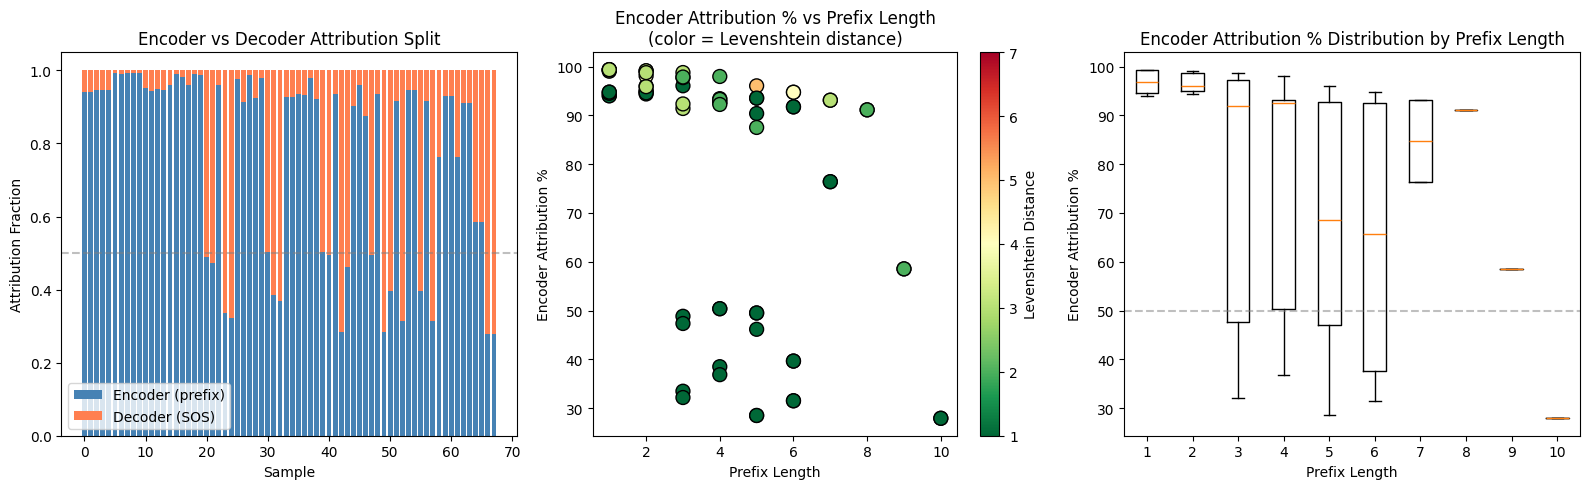


Summary Statistics:
  Mean encoder fraction: 77.7%
  Mean decoder fraction: 22.3%
  Min encoder fraction:  27.9%
  Max encoder fraction:  99.4%

By prefix length:
  Prefix 1: Encoder 96.9% ± 2.6%
  Prefix 2: Encoder 96.6% ± 2.0%
  Prefix 3: Encoder 73.6% ± 29.1%
  Prefix 4: Encoder 73.8% ± 26.0%
  Prefix 5: Encoder 66.3% ± 28.3%
  Prefix 6: Encoder 64.4% ± 31.0%
  Prefix 7: Encoder 84.8% ± 9.6%
  Prefix 8: Encoder 91.1% ± 0.0%
  Prefix 9: Encoder 58.5% ± 0.0%
  Prefix 10: Encoder 27.9% ± 0.0%


In [14]:
# Visualize encoder vs decoder attribution split
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Stacked bar chart of encoder vs decoder fractions
ax1 = axes[0]
x = range(len(ig_results_df))
ax1.bar(x, ig_results_df["encoder_fraction"], label="Encoder (prefix)", color="steelblue")
ax1.bar(x, ig_results_df["decoder_sos_fraction"], bottom=ig_results_df["encoder_fraction"], 
        label="Decoder (SOS)", color="coral")
ax1.set_xlabel("Sample")
ax1.set_ylabel("Attribution Fraction")
ax1.set_title("Encoder vs Decoder Attribution Split")
ax1.legend()
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Plot 2: Encoder fraction vs prefix length
ax2 = axes[1]
scatter = ax2.scatter(ig_results_df["prefix_len"], ig_results_df["encoder_fraction"] * 100, 
            c=ig_results_df["levenshtein_distance"], cmap="RdYlGn_r", s=100, edgecolor="black")
ax2.set_xlabel("Prefix Length")
ax2.set_ylabel("Encoder Attribution %")
ax2.set_title("Encoder Attribution % vs Prefix Length\n(color = Levenshtein distance)")
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label("Levenshtein Distance")

# Plot 3: Box plot by prefix length
ax3 = axes[2]
prefix_lens = sorted(ig_results_df["prefix_len"].unique())
box_data = [ig_results_df[ig_results_df["prefix_len"] == pl]["encoder_fraction"].values * 100 
            for pl in prefix_lens]
ax3.boxplot(box_data, labels=prefix_lens)
ax3.set_xlabel("Prefix Length")
ax3.set_ylabel("Encoder Attribution %")
ax3.set_title("Encoder Attribution % Distribution by Prefix Length")
ax3.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"  Mean encoder fraction: {ig_results_df['encoder_fraction'].mean()*100:.1f}%")
print(f"  Mean decoder fraction: {ig_results_df['decoder_sos_fraction'].mean()*100:.1f}%")
print(f"  Min encoder fraction:  {ig_results_df['encoder_fraction'].min()*100:.1f}%")
print(f"  Max encoder fraction:  {ig_results_df['encoder_fraction'].max()*100:.1f}%")

# Stats by prefix length
print("\nBy prefix length:")
for pl in prefix_lens:
    subset = ig_results_df[ig_results_df["prefix_len"] == pl]
    print(f"  Prefix {pl}: Encoder {subset['encoder_fraction'].mean()*100:.1f}% ± {subset['encoder_fraction'].std()*100:.1f}%")

In [15]:
# Compare best vs worst predictions
print("\nBest vs Worst Predictions - Encoder Attribution Comparison:")
print("=" * 60)

for pl in prefix_lens:
    best = ig_results_df[(ig_results_df["prefix_len"] == pl) & (ig_results_df["rank_type"] == "best")]
    worst = ig_results_df[(ig_results_df["prefix_len"] == pl) & (ig_results_df["rank_type"] == "worst")]
    
    if len(best) > 0 and len(worst) > 0:
        print(f"\nPrefix length {pl}:")
        print(f"  Best predictions:  Encoder {best['encoder_fraction'].mean()*100:.1f}% | Avg Levenshtein: {best['levenshtein_distance'].mean():.2f}")
        print(f"  Worst predictions: Encoder {worst['encoder_fraction'].mean()*100:.1f}% | Avg Levenshtein: {worst['levenshtein_distance'].mean():.2f}")


Best vs Worst Predictions - Encoder Attribution Comparison:

Prefix length 1:
  Best predictions:  Encoder 94.4% | Avg Levenshtein: 1.00
  Worst predictions: Encoder 99.3% | Avg Levenshtein: 4.40

Prefix length 2:
  Best predictions:  Encoder 95.0% | Avg Levenshtein: 1.00
  Worst predictions: Encoder 98.2% | Avg Levenshtein: 3.80

Prefix length 3:
  Best predictions:  Encoder 51.6% | Avg Levenshtein: 1.00
  Worst predictions: Encoder 95.6% | Avg Levenshtein: 3.40

Prefix length 4:
  Best predictions:  Encoder 62.2% | Avg Levenshtein: 1.00
  Worst predictions: Encoder 85.5% | Avg Levenshtein: 2.60

Prefix length 5:
  Best predictions:  Encoder 61.6% | Avg Levenshtein: 1.00
  Worst predictions: Encoder 71.0% | Avg Levenshtein: 2.00

Prefix length 6:
  Best predictions:  Encoder 64.4% | Avg Levenshtein: 1.75
  Worst predictions: Encoder 64.4% | Avg Levenshtein: 1.75

Prefix length 7:
  Best predictions:  Encoder 84.8% | Avg Levenshtein: 2.00
  Worst predictions: Encoder 84.8% | Avg Leven

## 9. Attribution Breakdown by Predicted Activity Class

For each activity the model can predict, analyze what input features drive that prediction.

In [16]:
# Get activity class information from the dataset
cat_categories = test_dataset.all_categories[0]
activity_info = cat_categories[0]  # First categorical feature is Activity

activity_name_col = activity_info[0]
n_activities = activity_info[1]
activity_idx_map = activity_info[2]

# Invert the mapping to get idx -> name
activity_classes = {v: k for k, v in activity_idx_map.items()}

print(f"Activity column: {activity_name_col}")
print(f"Number of activity classes: {n_activities}")
print(f"\nActivity classes:")
for idx in sorted(activity_classes.keys()):
    print(f"  {idx}: {activity_classes[idx]}")

Activity column: Activity
Number of activity classes: 16

Activity classes:
  1: Assign seriousness
  2: Closed
  3: Create SW anomaly
  4: DUPLICATE
  5: EOS
  6: INVALID
  7: Insert ticket
  8: RESOLVED
  9: Require upgrade
  10: Resolve SW anomaly
  11: Resolve ticket
  12: Schedule intervention
  13: Take in charge ticket
  14: VERIFIED
  15: Wait


In [17]:
# Sample prefixes and compute attributions targeting each activity class
SAMPLE_SIZE_ACTIVITY = 10  # Number of prefixes to sample
N_STEPS_ACTIVITY = 50

# Sample diverse prefixes from results
np.random.seed(42)
sample_indices = np.random.choice(len(results_df), 
                                   size=min(SAMPLE_SIZE_ACTIVITY, len(results_df)), 
                                   replace=False)
sample_rows = results_df.iloc[sample_indices]

print(f"Computing attributions for {len(sample_rows)} prefixes × {n_activities} activities...")
print(f"Total IG computations: {len(sample_rows) * n_activities}")

# Store results: for each activity, aggregate attributions across all sample prefixes
activity_feature_attributions = {idx: [] for idx in range(n_activities)}

for sample_idx, (_, row) in enumerate(tqdm(sample_rows.iterrows(), 
                                            total=len(sample_rows), 
                                            desc="Processing prefixes")):
    try:
        process_idx = int(row["database_index"])
        prefix_len = int(row["prefix_len"])
        
        # Load sample
        sample = test_dataset[process_idx]
        process = (sample[0], sample[1])
        
        # Compute attributions for each activity class
        for activity_idx in range(n_activities):
            try:
                attr_df = tool.compute_attribution_map(
                    process=process,
                    prefix_length=prefix_len,
                    target="Activity",
                    target_class=activity_idx,
                    suffix_scope="next",
                    method="integrated_gradients",
                    n_steps=N_STEPS_ACTIVITY
                )
                
                # Aggregate: mean absolute attribution per feature across timesteps
                feature_attrs = {}
                for col in attr_df.columns:
                    feature_attrs[col] = abs(attr_df[col]).mean()
                
                activity_feature_attributions[activity_idx].append(feature_attrs)
                
            except Exception as e:
                pass  # Skip failed computations
                
    except Exception as e:
        print(f"Error for sample {sample_idx}: {e}")

print(f"\nCompleted. Samples per activity: {[len(v) for v in activity_feature_attributions.values()]}")

Computing attributions for 10 prefixes × 16 activities...
Total IG computations: 160


Processing prefixes:   0%|          | 0/10 [00:00<?, ?it/s]

Error for sample 0: 'database_index'
Error for sample 1: 'database_index'
Error for sample 2: 'database_index'
Error for sample 3: 'database_index'
Error for sample 4: 'database_index'
Error for sample 5: 'database_index'
Error for sample 6: 'database_index'
Error for sample 7: 'database_index'
Error for sample 8: 'database_index'
Error for sample 9: 'database_index'

Completed. Samples per activity: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 10. Save Results

In [18]:
import pickle

# Save results
output_filename = "single_attribution_analysis_results.pkl"

with open(output_filename, 'wb') as f:
    pickle.dump({
        'all_results': results_df.to_dict('records'),
        'selected_results': selected_rows.to_dict('records'),
        'ig_results': ig_results,
        'ig_results_df': ig_results_df.to_dict('records'),
        'activity_feature_attributions': activity_feature_attributions,
        'config': {
            'max_cases': MAX_CASES,
            'top_n_per_prefix': TOP_N_PER_PREFIX,
            'ig_steps': IG_STEPS
        }
    }, f)

print(f"Results saved to: {output_filename}")

Results saved to: single_attribution_analysis_results.pkl
